<a href="https://colab.research.google.com/github/Ololade18/CMP7239CW2/blob/main/Ololade_NVD_DATASET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/drive')

import pandas as pd

df = pd.read_csv("/drive/MyDrive/Colab Notebooks/NVD_Cybersecurity_Dataset.csv")

print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nFirst 3 rows:\n", df.head(3))
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic stats:\n", df.describe())

Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
Shape: (337705, 19)

Column names:
 ['CVE_ID', 'Published_Date', 'Publish_Year', 'Publish_Month', 'Description', 'Clean_Description', 'Word_Count', 'Char_Length', 'Flag_XSS', 'Flag_SQLi', 'Flag_Buffer_Overflow', 'Flag_RCE', 'Flag_Privilege_Escalation', 'Flag_DoS', 'Flag_Directory_Traversal', 'CVSS_Base_Score', 'Severity', 'Exploitability_Score', 'Impact_Score']

First 3 rows:
           CVE_ID Published_Date  Publish_Year  Publish_Month  \
0  CVE-1999-0095     1988-10-01          1988             10   
1  CVE-1999-0082     1988-11-11          1988             11   
2  CVE-1999-1471     1989-01-01          1989              1   

                                         Description  \
0  The debug command in Sendmail is enabled, allo...   
1      CWD ~root command in ftpd allows root access.   
2  Buffer overflow in passwd in BSD based operati...   

                         

In [ ]:
print("Severity distribution:\n", df["Severity"].value_counts())
print("\nCVSS score sample values:\n", df["CVSS_Base_Score"].value_counts().head(20))
print("\nYear range:", df["Publish_Year"].min(), "to", df["Publish_Year"].max())

Severity distribution:
 Severity
MEDIUM      148626
HIGH        123452
CRITICAL     29743
UNKNOWN      22007
LOW          13849
NONE            28
Name: count, dtype: int64

CVSS score sample values:
 CVSS_Base_Score
7.5     36747
7.8     23250
9.8     23127
0.0     22057
4.3     19948
8.8     19193
6.5     18078
5.5     17675
6.1     12743
5.4     12532
5.0     11749
5.3      9426
6.8      7281
7.2      6792
10.0     6215
7.1      6013
9.3      5121
6.3      4951
6.4      4452
8.1      4395
Name: count, dtype: int64

Year range: 1988 to 2026


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/drive/MyDrive/Colab Notebooks/NVD_Cybersecurity_Dataset.csv")

print("Original shape:", df.shape)

# Drop UNKNOWN and NONE severity
df = df[~df["Severity"].isin(["UNKNOWN", "NONE"])]
print("After dropping UNKNOWN/NONE:", df.shape)

# Drop zero scores
df = df[df["CVSS_Base_Score"] > 0]
print("After dropping zero scores:", df.shape)

# Check severity distribution after cleaning
print("\nCleaned severity distribution:")
print(df["Severity"].value_counts())
print("\nSeverity percentages:")
print(df["Severity"].value_counts(normalize=True).round(3) * 100)

Original shape: (337705, 19)
After dropping UNKNOWN/NONE: (315670, 19)
After dropping zero scores: (315648, 19)

Cleaned severity distribution:
Severity
MEDIUM      148626
HIGH        123452
CRITICAL     29743
LOW          13827
Name: count, dtype: int64

Severity percentages:
Severity
MEDIUM      47.1
HIGH        39.1
CRITICAL     9.4
LOW          4.4
Name: proportion, dtype: float64


In [ ]:
total = 20000
proportions = df["Severity"].value_counts(normalize=True)

print("Sampling targets:")
for sev, prop in proportions.items():
    print(f"  {sev}: {round(prop * total)}")

df_sample = df.groupby("Severity", group_keys=False).apply(
    lambda x: x.sample(n=round(proportions[x.name] * total), random_state=42)
)

df_sample = df_sample.reset_index(drop=True)
print(f"\nFinal sample shape: {df_sample.shape}")
print("\nSample severity distribution:")
print(df_sample["Severity"].value_counts())

df_sample.to_csv("/drive/MyDrive/Colab Notebooks/NVD_sample_20k.csv", index=False)
print("\nSaved.")

Sampling targets:
  MEDIUM: 9417
  HIGH: 7822
  CRITICAL: 1885
  LOW: 876


/tmp/ipykernel_1263/1393633696.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby("Severity", group_keys=False).apply(



Final sample shape: (20000, 19)

Sample severity distribution:
Severity
MEDIUM      9417
HIGH        7822
CRITICAL    1885
LOW          876
Name: count, dtype: int64

Saved.


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/drive/MyDrive/Colab Notebooks/NVD_sample_20k.csv")

# --- DATE FEATURES ---
df["Published_Date"] = pd.to_datetime(df["Published_Date"])
df["pub_day_of_week"] = df["Published_Date"].dt.dayofweek
df["pub_quarter"] = df["Published_Date"].dt.quarter
df["days_since_published"] = (pd.Timestamp.now() - df["Published_Date"]).dt.days

# --- SEVERITY ENCODING ---
severity_map = {"LOW": 1, "MEDIUM": 2, "HIGH": 3, "CRITICAL": 4}
df["severity_encoded"] = df["Severity"].map(severity_map)

# --- INTERACTION FEATURES ---
df["rce_x_word_count"] = df["Flag_RCE"] * df["Word_Count"]
df["dos_x_char_length"] = df["Flag_DoS"] * df["Char_Length"]
df["xss_x_sqli"] = df["Flag_XSS"] * df["Flag_SQLi"]
df["buffer_x_rce"] = df["Flag_Buffer_Overflow"] * df["Flag_RCE"]
df["priv_x_rce"] = df["Flag_Privilege_Escalation"] * df["Flag_RCE"]
df["total_flags"] = (df["Flag_XSS"] + df["Flag_SQLi"] + df["Flag_Buffer_Overflow"] +
                     df["Flag_RCE"] + df["Flag_Privilege_Escalation"] +
                     df["Flag_DoS"] + df["Flag_Directory_Traversal"])
df["multi_flag"] = (df["total_flags"] > 1).astype(int)

# --- YEAR FEATURES ---
df["years_since_2000"] = df["Publish_Year"] - 2000
df["is_recent"] = (df["Publish_Year"] >= 2020).astype(int)
df["is_pre_cvss3"] = (df["Publish_Year"] < 2016).astype(int)

# --- TEXT FEATURES ---
df["word_count_bin"] = pd.cut(df["Word_Count"], bins=[0,20,40,60,100,700], labels=[0,1,2,3,4]).astype(float)
df["char_length_bin"] = pd.cut(df["Char_Length"], bins=[0,100,200,400,800,5000], labels=[0,1,2,3,4]).astype(float)
df["desc_density"] = df["Char_Length"] / (df["Word_Count"] + 1)

# --- MONTH CYCLICAL ENCODING ---
# Converts month into sine/cosine to capture cyclical nature (Dec close to Jan)
df["month_sin"] = np.sin(2 * np.pi * df["Publish_Month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["Publish_Month"] / 12)
df["dow_sin"] = np.sin(2 * np.pi * df["pub_day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["pub_day_of_week"] / 7)

# --- DROP LEAKAGE AND NON-FEATURE COLUMNS ---
df = df.drop(columns=[
    "CVE_ID", "Published_Date", "Description", "Clean_Description",
    "Severity", "Exploitability_Score", "Impact_Score"
])

print("Final shape:", df.shape)
print("\nAll columns:\n", df.columns.tolist())
print("\nMissing values:", df.isnull().sum().sum())

df.to_csv("/drive/MyDrive/Colab Notebooks/NVD_engineered_20k.csv", index=False)
print("\nSaved.")

Final shape: (20000, 33)

All columns:
 ['Publish_Year', 'Publish_Month', 'Word_Count', 'Char_Length', 'Flag_XSS', 'Flag_SQLi', 'Flag_Buffer_Overflow', 'Flag_RCE', 'Flag_Privilege_Escalation', 'Flag_DoS', 'Flag_Directory_Traversal', 'CVSS_Base_Score', 'pub_day_of_week', 'pub_quarter', 'days_since_published', 'severity_encoded', 'rce_x_word_count', 'dos_x_char_length', 'xss_x_sqli', 'buffer_x_rce', 'priv_x_rce', 'total_flags', 'multi_flag', 'years_since_2000', 'is_recent', 'is_pre_cvss3', 'word_count_bin', 'char_length_bin', 'desc_density', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']

Missing values: 0

Saved.


In [ ]:
df = pd.read_csv("/drive/MyDrive/Colab Notebooks/NVD_engineered_20k.csv")

# --- POLYNOMIAL FEATURES ON KEY COLUMNS ---
df["word_count_sq"] = df["Word_Count"] ** 2
df["char_length_sq"] = df["Char_Length"] ** 2
df["word_count_log"] = np.log1p(df["Word_Count"])
df["char_length_log"] = np.log1p(df["Char_Length"])
df["days_since_log"] = np.log1p(df["days_since_published"])

# --- FLAG RATIOS AND COMBINATIONS ---
df["flag_density"] = df["total_flags"] / (df["Word_Count"] + 1)
df["rce_or_priv"] = ((df["Flag_RCE"] == 1) | (df["Flag_Privilege_Escalation"] == 1)).astype(int)
df["xss_or_sqli"] = ((df["Flag_XSS"] == 1) | (df["Flag_SQLi"] == 1)).astype(int)
df["critical_combo"] = ((df["Flag_RCE"] == 1) & (df["Flag_Privilege_Escalation"] == 1)).astype(int)
df["no_flags"] = (df["total_flags"] == 0).astype(int)

# --- YEAR BINS ---
df["era_pre2010"] = (df["Publish_Year"] < 2010).astype(int)
df["era_2010_2015"] = ((df["Publish_Year"] >= 2010) & (df["Publish_Year"] < 2015)).astype(int)
df["era_2015_2020"] = ((df["Publish_Year"] >= 2015) & (df["Publish_Year"] < 2020)).astype(int)
df["era_post2020"] = (df["Publish_Year"] >= 2020).astype(int)

# --- SEVERITY INTERACTIONS ---
df["severity_x_flags"] = df["severity_encoded"] * df["total_flags"]
df["severity_x_word_count"] = df["severity_encoded"] * df["Word_Count"]
df["severity_x_rce"] = df["severity_encoded"] * df["Flag_RCE"]

# --- QUARTER DUMMIES ---
for q in [1, 2, 3, 4]:
    df[f"quarter_{q}"] = (df["pub_quarter"] == q).astype(int)

print("Final shape:", df.shape)
print("\nAll columns:\n", df.columns.tolist())
print("\nMissing values:", df.isnull().sum().sum())

df.to_csv("/drive/MyDrive/Colab Notebooks/NVD_engineered_20k.csv", index=False)
print("\nSaved.")

Final shape: (20000, 54)

All columns:
 ['Publish_Year', 'Publish_Month', 'Word_Count', 'Char_Length', 'Flag_XSS', 'Flag_SQLi', 'Flag_Buffer_Overflow', 'Flag_RCE', 'Flag_Privilege_Escalation', 'Flag_DoS', 'Flag_Directory_Traversal', 'CVSS_Base_Score', 'pub_day_of_week', 'pub_quarter', 'days_since_published', 'severity_encoded', 'rce_x_word_count', 'dos_x_char_length', 'xss_x_sqli', 'buffer_x_rce', 'priv_x_rce', 'total_flags', 'multi_flag', 'years_since_2000', 'is_recent', 'is_pre_cvss3', 'word_count_bin', 'char_length_bin', 'desc_density', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'word_count_sq', 'char_length_sq', 'word_count_log', 'char_length_log', 'days_since_log', 'flag_density', 'rce_or_priv', 'xss_or_sqli', 'critical_combo', 'no_flags', 'era_pre2010', 'era_2010_2015', 'era_2015_2020', 'era_post2020', 'severity_x_flags', 'severity_x_word_count', 'severity_x_rce', 'quarter_1', 'quarter_2', 'quarter_3', 'quarter_4']

Missing values: 0

Saved.


In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

df = pd.read_csv("/drive/MyDrive/Colab Notebooks/NVD_engineered_20k.csv")

X = df.drop(columns=["CVSS_Base_Score"])
y = df["CVSS_Base_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}
cv_results = {}

print("Setup done.")
print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])
print("Features:", X_train.shape[1])

Setup done.
Training samples: 16000
Test samples: 4000
Features: 53


In [ ]:
df = pd.read_csv("/drive/MyDrive/Colab Notebooks/NVD_engineered_20k.csv")

X = df.drop(columns=["CVSS_Base_Score",
                      "severity_x_flags",
                      "severity_x_word_count",
                      "severity_x_rce"])
y = df["CVSS_Base_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}
cv_results = {}

print("Features:", X.shape[1])

Features: 50


In [ ]:
lr = LinearRegression()
lr_cv = cross_val_score(lr, X_train_scaled, y_train, cv=kf, scoring="r2")
lr.fit(X_train_scaled, y_train)
preds_lr = lr.predict(X_test_scaled)

mae = mean_absolute_error(y_test, preds_lr)
rmse = np.sqrt(mean_squared_error(y_test, preds_lr))
r2 = r2_score(y_test, preds_lr)

results["Linear Regression"] = {"MAE": round(mae,4), "RMSE": round(rmse,4), "R2": round(r2,4)}
cv_results["Linear Regression"] = {"CV R2 Mean": round(lr_cv.mean(),4), "CV R2 Std": round(lr_cv.std(),4)}
print(f"Linear Regression | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
print(f"  CV R2: {lr_cv.mean():.4f} (+/- {lr_cv.std():.4f})")

Linear Regression | MAE: 0.5753 | RMSE: 0.7376 | R2: 0.8280
  CV R2: 0.8339 (+/- 0.0064)


In [ ]:
ridge = Ridge(alpha=1.0)
ridge_cv = cross_val_score(ridge, X_train_scaled, y_train, cv=kf, scoring="r2")
ridge.fit(X_train_scaled, y_train)
preds_ridge = ridge.predict(X_test_scaled)

mae = mean_absolute_error(y_test, preds_ridge)
rmse = np.sqrt(mean_squared_error(y_test, preds_ridge))
r2 = r2_score(y_test, preds_ridge)

results["Ridge Regression"] = {"MAE": round(mae,4), "RMSE": round(rmse,4), "R2": round(r2,4)}
cv_results["Ridge Regression"] = {"CV R2 Mean": round(ridge_cv.mean(),4), "CV R2 Std": round(ridge_cv.std(),4)}
print(f"Ridge Regression | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
print(f"  CV R2: {ridge_cv.mean():.4f} (+/- {ridge_cv.std():.4f})")

Ridge Regression | MAE: 0.5753 | RMSE: 0.7376 | R2: 0.8280
  CV R2: 0.8339 (+/- 0.0064)


In [ ]:
lasso = Lasso(alpha=0.01)
lasso_cv = cross_val_score(lasso, X_train_scaled, y_train, cv=kf, scoring="r2")
lasso.fit(X_train_scaled, y_train)
preds_lasso = lasso.predict(X_test_scaled)

mae = mean_absolute_error(y_test, preds_lasso)
rmse = np.sqrt(mean_squared_error(y_test, preds_lasso))
r2 = r2_score(y_test, preds_lasso)

results["Lasso Regression"] = {"MAE": round(mae,4), "RMSE": round(rmse,4), "R2": round(r2,4)}
cv_results["Lasso Regression"] = {"CV R2 Mean": round(lasso_cv.mean(),4), "CV R2 Std": round(lasso_cv.std(),4)}
print(f"Lasso Regression | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
print(f"  CV R2: {lasso_cv.mean():.4f} (+/- {lasso_cv.std():.4f})")

Lasso Regression | MAE: 0.5771 | RMSE: 0.7396 | R2: 0.8270
  CV R2: 0.8335 (+/- 0.0065)


In [ ]:
svr = SVR(kernel="rbf", C=10, epsilon=0.1)
svr_cv = cross_val_score(svr, X_train_scaled, y_train, cv=kf, scoring="r2")
svr.fit(X_train_scaled, y_train)
preds_svr = svr.predict(X_test_scaled)

mae = mean_absolute_error(y_test, preds_svr)
rmse = np.sqrt(mean_squared_error(y_test, preds_svr))
r2 = r2_score(y_test, preds_svr)

results["SVR"] = {"MAE": round(mae,4), "RMSE": round(rmse,4), "R2": round(r2,4)}
cv_results["SVR"] = {"CV R2 Mean": round(svr_cv.mean(),4), "CV R2 Std": round(svr_cv.std(),4)}
print(f"SVR | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
print(f"  CV R2: {svr_cv.mean():.4f} (+/- {svr_cv.std():.4f})")

SVR | MAE: 0.5036 | RMSE: 0.7053 | R2: 0.8428
  CV R2: 0.8460 (+/- 0.0061)


In [ ]:
xgb = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb_cv = cross_val_score(xgb, X_train, y_train, cv=kf, scoring="r2")
xgb.fit(X_train, y_train)
preds_xgb = xgb.predict(X_test)

mae = mean_absolute_error(y_test, preds_xgb)
rmse = np.sqrt(mean_squared_error(y_test, preds_xgb))
r2 = r2_score(y_test, preds_xgb)

results["XGBoost"] = {"MAE": round(mae,4), "RMSE": round(rmse,4), "R2": round(r2,4)}
cv_results["XGBoost"] = {"CV R2 Mean": round(xgb_cv.mean(),4), "CV R2 Std": round(xgb_cv.std(),4)}
print(f"XGBoost | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
print(f"  CV R2: {xgb_cv.mean():.4f} (+/- {xgb_cv.std():.4f})")

XGBoost | MAE: 0.5106 | RMSE: 0.6712 | R2: 0.8576
  CV R2: 0.8627 (+/- 0.0068)


In [ ]:
tf.random.set_seed(42)

mlp_basic = keras.Sequential([
    layers.Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

mlp_basic.compile(optimizer="adam", loss="mse", metrics=["mae"])

history_basic = mlp_basic.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=256,
    callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=0
)

preds_mlp_basic = mlp_basic.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, preds_mlp_basic)
rmse = np.sqrt(mean_squared_error(y_test, preds_mlp_basic))
r2 = r2_score(y_test, preds_mlp_basic)

results["MLP Basic"] = {"MAE": round(mae,4), "RMSE": round(rmse,4), "R2": round(r2,4)}
cv_results["MLP Basic"] = {"CV R2 Mean": "—", "CV R2 Std": "—"}
print(f"MLP Basic | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
print(f"  Epochs trained: {len(history_basic.history['loss'])}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MLP Basic | MAE: 0.5326 | RMSE: 0.6837 | R2: 0.8522
  Epochs trained: 32


In [ ]:
tf.random.set_seed(42)

mlp_dropout = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.1),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.1),
    layers.Dense(64, activation="relu"),
    layers.Dense(1)
])

mlp_dropout.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse", metrics=["mae"])

history_dropout = mlp_dropout.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=200,
    batch_size=128,
    callbacks=[keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)],
    verbose=0
)

preds_mlp_dropout = mlp_dropout.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, preds_mlp_dropout)
rmse = np.sqrt(mean_squared_error(y_test, preds_mlp_dropout))
r2 = r2_score(y_test, preds_mlp_dropout)

results["MLP Dropout"] = {"MAE": round(mae,4), "RMSE": round(rmse,4), "R2": round(r2,4)}
cv_results["MLP Dropout"] = {"CV R2 Mean": "—", "CV R2 Std": "—"}
print(f"MLP Dropout | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
print(f"  Epochs trained: {len(history_dropout.history['loss'])}")

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MLP Dropout | MAE: 0.5584 | RMSE: 0.7359 | R2: 0.8288
  Epochs trained: 23


In [ ]:
print("\n--- Test Set Results ---")
results_df = pd.DataFrame(results).T
print(results_df)

print("\n--- Cross Validation Results ---")
cv_df = pd.DataFrame(cv_results).T
print(cv_df)


--- Test Set Results ---
                      MAE    RMSE      R2
Linear Regression  0.5753  0.7376  0.8280
Ridge Regression   0.5753  0.7376  0.8280
Lasso Regression   0.5771  0.7396  0.8270
SVR                0.5036  0.7053  0.8428
XGBoost            0.5106  0.6712  0.8576
MLP Basic          0.5326  0.6837  0.8522
MLP Dropout        0.5584  0.7359  0.8288

--- Cross Validation Results ---
                  CV R2 Mean CV R2 Std
Linear Regression     0.8339    0.0064
Ridge Regression      0.8339    0.0064
Lasso Regression      0.8335    0.0065
SVR                    0.846    0.0061
XGBoost               0.8627    0.0068
MLP Basic                  —         —
MLP Dropout                —         —


In [ ]:
import joblib

joblib.dump(lr, "/drive/MyDrive/Colab Notebooks/linear_regression.model")
joblib.dump(ridge, "/drive/MyDrive/Colab Notebooks/ridge_regression.model")
joblib.dump(lasso, "/drive/MyDrive/Colab Notebooks/lasso_regression.model")
joblib.dump(svr, "/drive/MyDrive/Colab Notebooks/svr.model")
joblib.dump(xgb, "/drive/MyDrive/Colab Notebooks/xgboost.model")
mlp_basic.save("/drive/MyDrive/Colab Notebooks/mlp_basic.keras")
mlp_dropout.save("/drive/MyDrive/Colab Notebooks/mlp_dropout.keras")

print("All 7 models saved.")

All 7 models saved.


In [ ]:
import pickle

with open("/drive/MyDrive/Colab Notebooks/linear_regression.pkl", "wb") as f:
    pickle.dump(lr, f)

with open("/drive/MyDrive/Colab Notebooks/ridge_regression.pkl", "wb") as f:
    pickle.dump(ridge, f)

with open("/drive/MyDrive/Colab Notebooks/lasso_regression.pkl", "wb") as f:
    pickle.dump(lasso, f)

with open("/drive/MyDrive/Colab Notebooks/svr.pkl", "wb") as f:
    pickle.dump(svr, f)

with open("/drive/MyDrive/Colab Notebooks/xgboost.pkl", "wb") as f:
    pickle.dump(xgb, f)

print("All 5 sklearn models saved as pickle files.")
print("Note: Keras models saved as .keras format — pickle not recommended for TensorFlow models.")

All 5 sklearn models saved as pickle files.
Note: Keras models saved as .keras format — pickle not recommended for TensorFlow models.


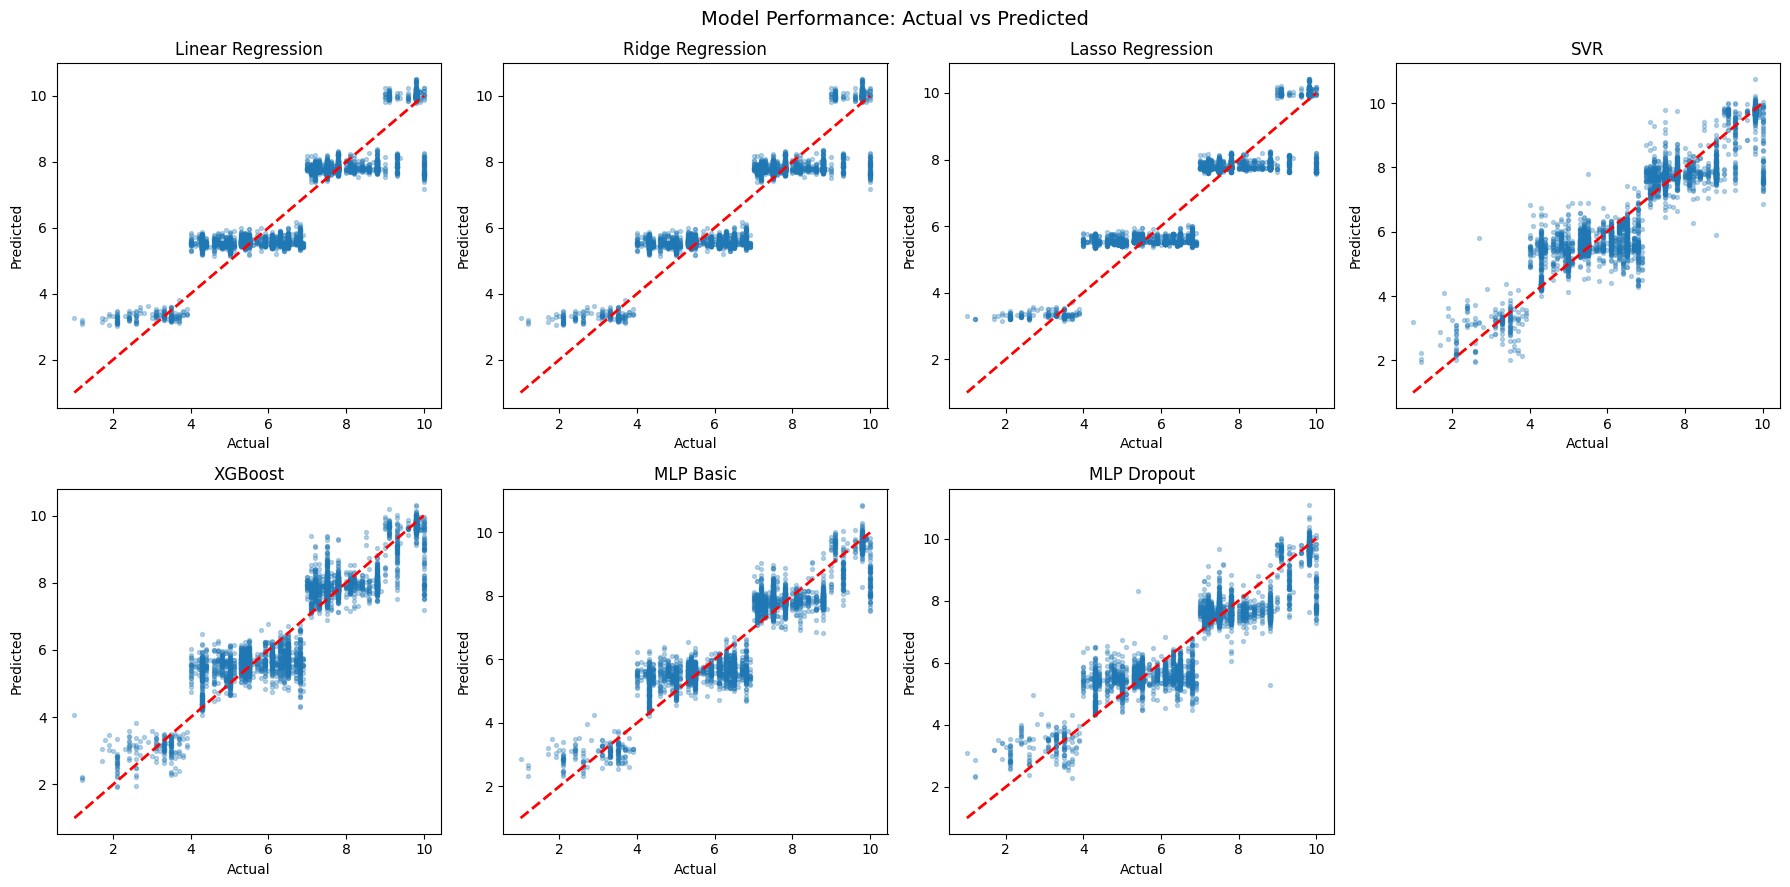

Saved.


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Model Performance: Actual vs Predicted", fontsize=14)

model_preds = {
    "Linear Regression": preds_lr,
    "Ridge Regression": preds_ridge,
    "Lasso Regression": preds_lasso,
    "SVR": preds_svr,
    "XGBoost": preds_xgb,
    "MLP Basic": preds_mlp_basic,
    "MLP Dropout": preds_mlp_dropout
}

for ax, (name, preds) in zip(axes.flatten(), model_preds.items()):
    ax.scatter(y_test, preds, alpha=0.3, s=8)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(name)

axes[1, 3].axis("off")
plt.tight_layout()
plt.savefig("/drive/MyDrive/Colab Notebooks/actual_vs_predicted.png", dpi=150)
plt.show()
print("Saved.")

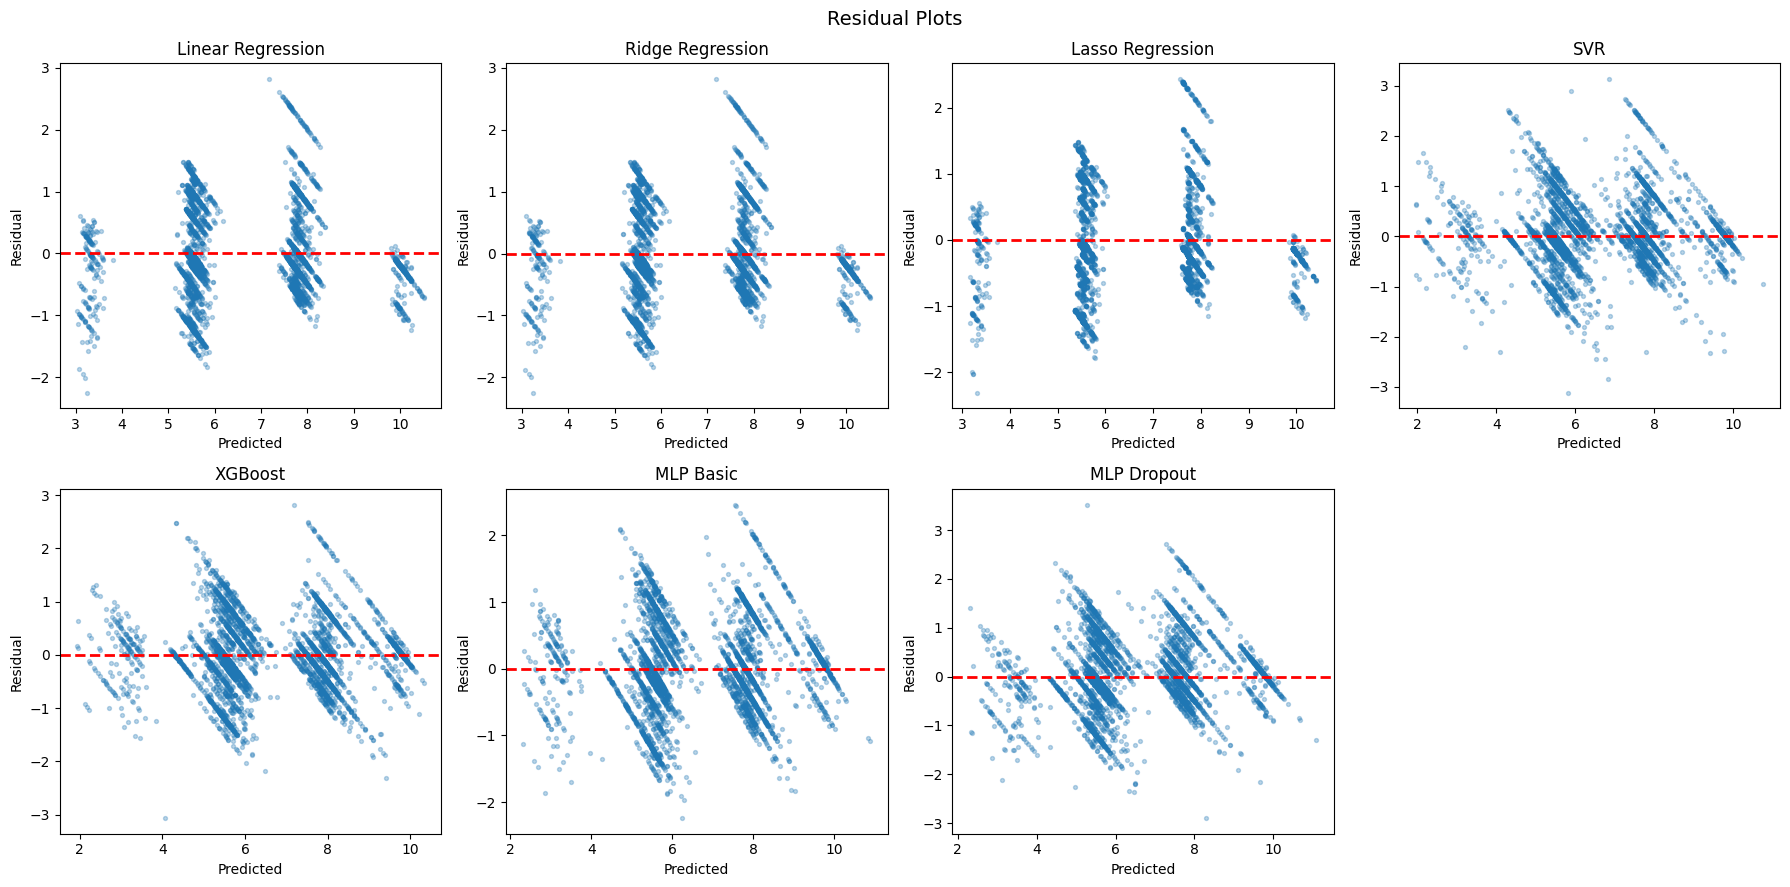

Saved.


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Residual Plots", fontsize=14)

for ax, (name, preds) in zip(axes.flatten(), model_preds.items()):
    residuals = y_test - preds
    ax.scatter(preds, residuals, alpha=0.3, s=8)
    ax.axhline(0, color='r', linestyle='--', lw=2)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual")
    ax.set_title(name)

axes[1, 3].axis("off")
plt.tight_layout()
plt.savefig("/drive/MyDrive/Colab Notebooks/residual_plots.png", dpi=150)
plt.show()
print("Saved.")

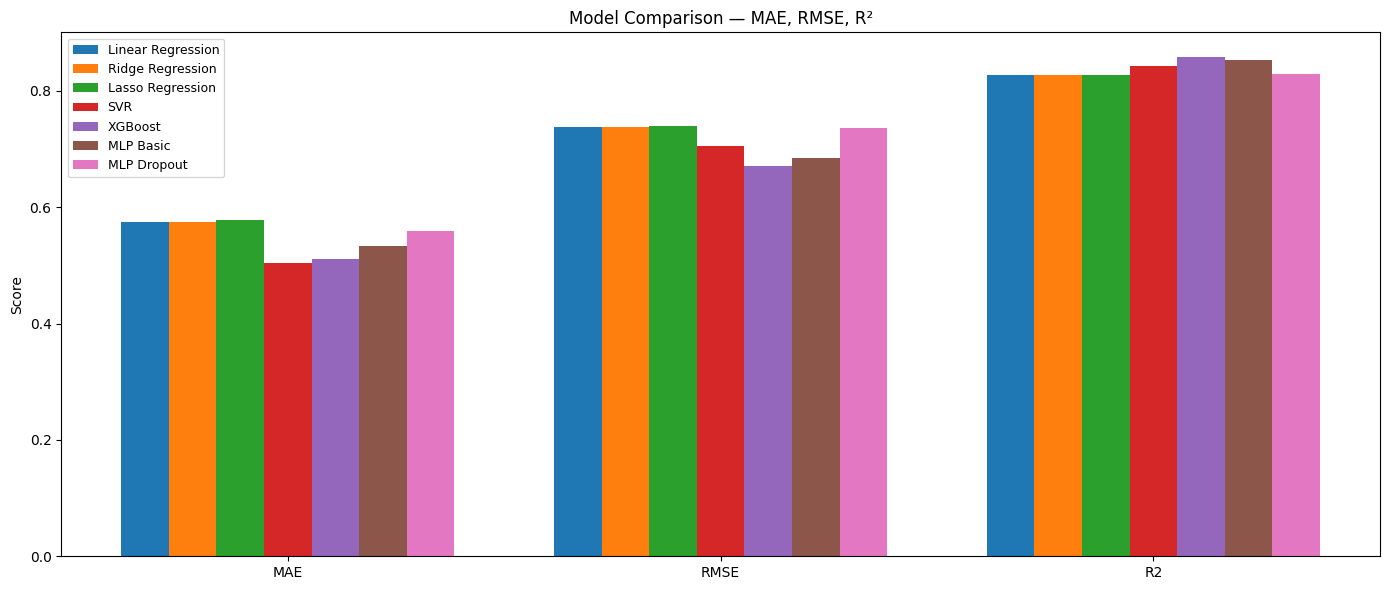

Saved.


In [ ]:
metrics = ["MAE", "RMSE", "R2"]
x = np.arange(len(metrics))
width = 0.11

fig, ax = plt.subplots(figsize=(14, 6))

for i, (name, scores) in enumerate(results.items()):
    values = [scores["MAE"], scores["RMSE"], scores["R2"]]
    ax.bar(x + i * width, values, width, label=name)

ax.set_xticks(x + width * 3)
ax.set_xticklabels(metrics)
ax.set_title("Model Comparison — MAE, RMSE, R²")
ax.set_ylabel("Score")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("/drive/MyDrive/Colab Notebooks/model_comparison.png", dpi=150)
plt.show()
print("Saved.")

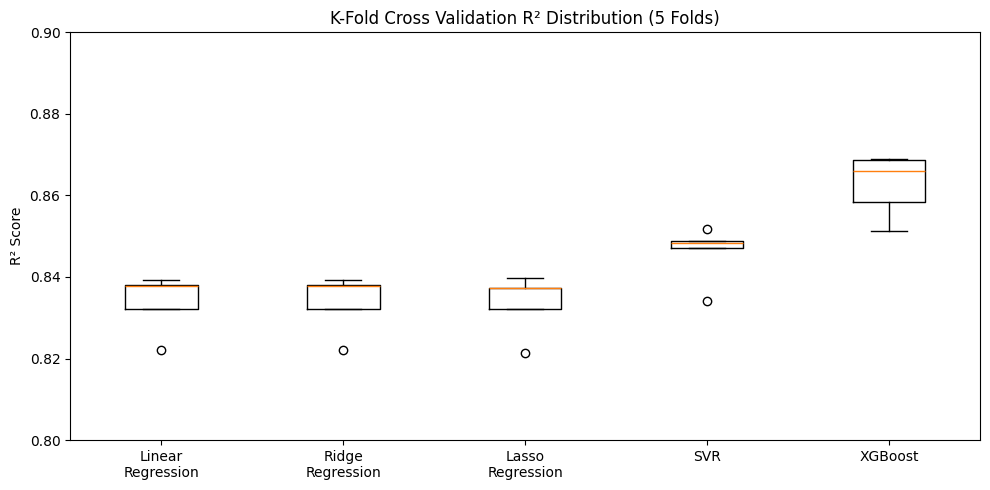

Saved.


In [ ]:
cv_data = {
    "Linear\nRegression": lr_cv,
    "Ridge\nRegression": ridge_cv,
    "Lasso\nRegression": lasso_cv,
    "SVR": svr_cv,
    "XGBoost": xgb_cv
}

fig, ax = plt.subplots(figsize=(10, 5))
positions = range(len(cv_data))
for pos, (name, scores) in zip(positions, cv_data.items()):
    ax.boxplot(scores, positions=[pos], widths=0.4)

ax.set_xticks(list(positions))
ax.set_xticklabels(list(cv_data.keys()))
ax.set_title("K-Fold Cross Validation R² Distribution (5 Folds)")
ax.set_ylabel("R² Score")
ax.set_ylim(0.80, 0.90)
plt.tight_layout()
plt.savefig("/drive/MyDrive/Colab Notebooks/cv_stability.png", dpi=150)
plt.show()
print("Saved.")

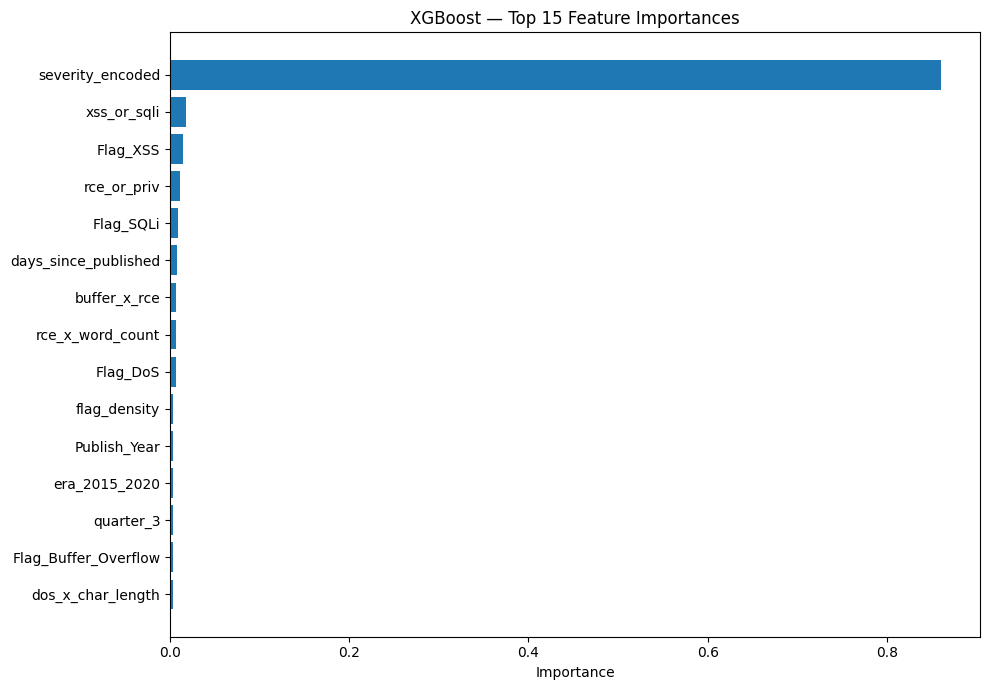

Saved.


In [ ]:
feature_names = X_train.columns
xgb_importance = pd.Series(xgb.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(xgb_importance.index[::-1], xgb_importance.values[::-1])
ax.set_title("XGBoost — Top 15 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("/drive/MyDrive/Colab Notebooks/feature_importance.png", dpi=150)
plt.show()
print("Saved.")

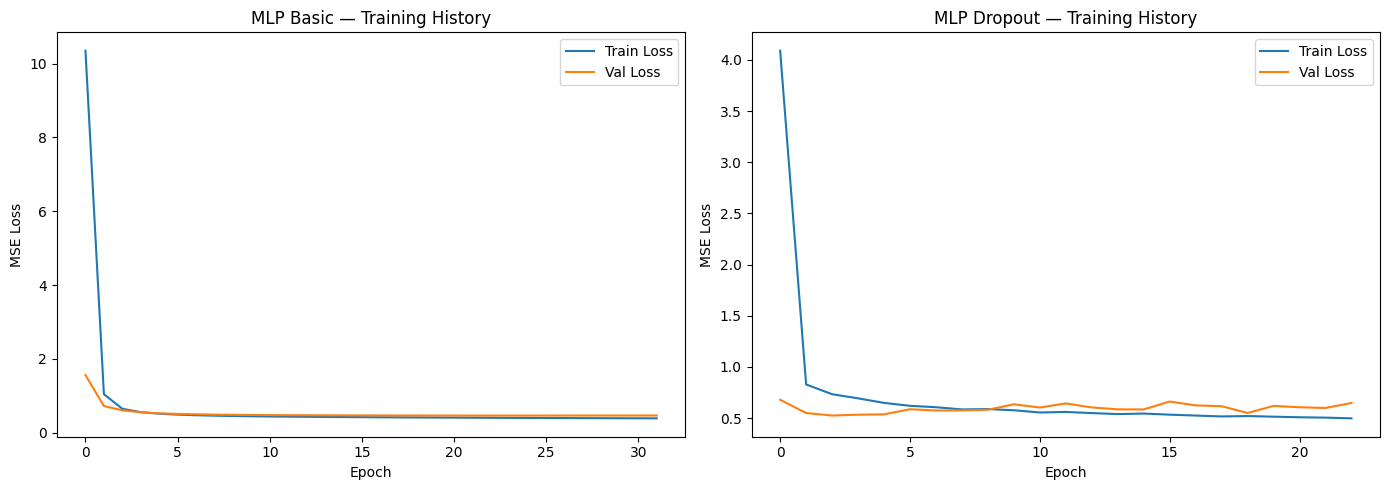

Saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_basic.history["loss"], label="Train Loss")
axes[0].plot(history_basic.history["val_loss"], label="Val Loss")
axes[0].set_title("MLP Basic — Training History")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()

axes[1].plot(history_dropout.history["loss"], label="Train Loss")
axes[1].plot(history_dropout.history["val_loss"], label="Val Loss")
axes[1].set_title("MLP Dropout — Training History")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig("/drive/MyDrive/Colab Notebooks/deep_learning_history.png", dpi=150)
plt.show()
print("Saved.")

In [ ]:
joblib.dump(lr, "/drive/MyDrive/Colab Notebooks/linear_regression.model")
joblib.dump(ridge, "/drive/MyDrive/Colab Notebooks/ridge_regression.model")
joblib.dump(lasso, "/drive/MyDrive/Colab Notebooks/lasso_regression.model")
joblib.dump(svr, "/drive/MyDrive/Colab Notebooks/svr.model")
joblib.dump(xgb, "/drive/MyDrive/Colab Notebooks/xgboost.model")
mlp_basic.save("/drive/MyDrive/Colab Notebooks/mlp_basic.keras")
mlp_dropout.save("/drive/MyDrive/Colab Notebooks/mlp_dropout.keras")
print("All 7 models saved.")


All 7 models saved.


In [ ]:
X_full_clean = df_engineered.drop(columns=["CVSS_Base_Score",
                                            "severity_x_flags",
                                            "severity_x_word_count",
                                            "severity_x_rce"])
y_full = df_engineered["CVSS_Base_Score"]

predicted_scores = xgb.predict(X_full_clean)
actual_scores = y_full.values

residuals = actual_scores - predicted_scores
abs_residuals = np.abs(residuals)

threshold = np.percentile(abs_residuals, 90)
print(f"Inconsistency threshold (90th percentile): {threshold:.4f}")

df_raw = pd.read_csv("/drive/MyDrive/Colab Notebooks/NVD_sample_20k.csv")

inconsistency_df = pd.DataFrame({
    "cve_id": df_raw["CVE_ID"].values,
    "actual_score": actual_scores,
    "predicted_score": predicted_scores.round(4),
    "residual": residuals.round(4),
    "abs_residual": abs_residuals.round(4),
    "flagged": abs_residuals > threshold
})

print(f"\nTotal CVEs flagged: {inconsistency_df['flagged'].sum()}")
print(f"That is {inconsistency_df['flagged'].mean()*100:.1f}% of the dataset")
print(f"\nTop 10 most inconsistent CVEs:")
print(inconsistency_df.sort_values("abs_residual", ascending=False).head(10))

Inconsistency threshold (90th percentile): 0.9093

Total CVEs flagged: 2000
That is 10.0% of the dataset

Top 10 most inconsistent CVEs:
              cve_id  actual_score  predicted_score  residual  abs_residual  \
10170  CVE-2010-2389           1.0           4.0621   -3.0621        3.0621   
6698   CVE-1999-0095          10.0           7.1767    2.8233        2.8233   
7348   CVE-2005-0491          10.0           7.5126    2.4874        2.4874   
7286   CVE-2011-4755          10.0           7.5181    2.4819        2.4819   
18169  CVE-2013-2710           6.8           4.3181    2.4819        2.4819   
11465  CVE-2007-2090           6.8           4.3212    2.4788        2.4788   
5227   CVE-1999-0799          10.0           7.5539    2.4461        2.4461   
5135   CVE-2000-0798          10.0           7.6263    2.3737        2.3737   
6220   CVE-2005-3449          10.0           7.6352    2.3648        2.3648   
2414   CVE-2011-3099          10.0           7.6600    2.3400        2.34

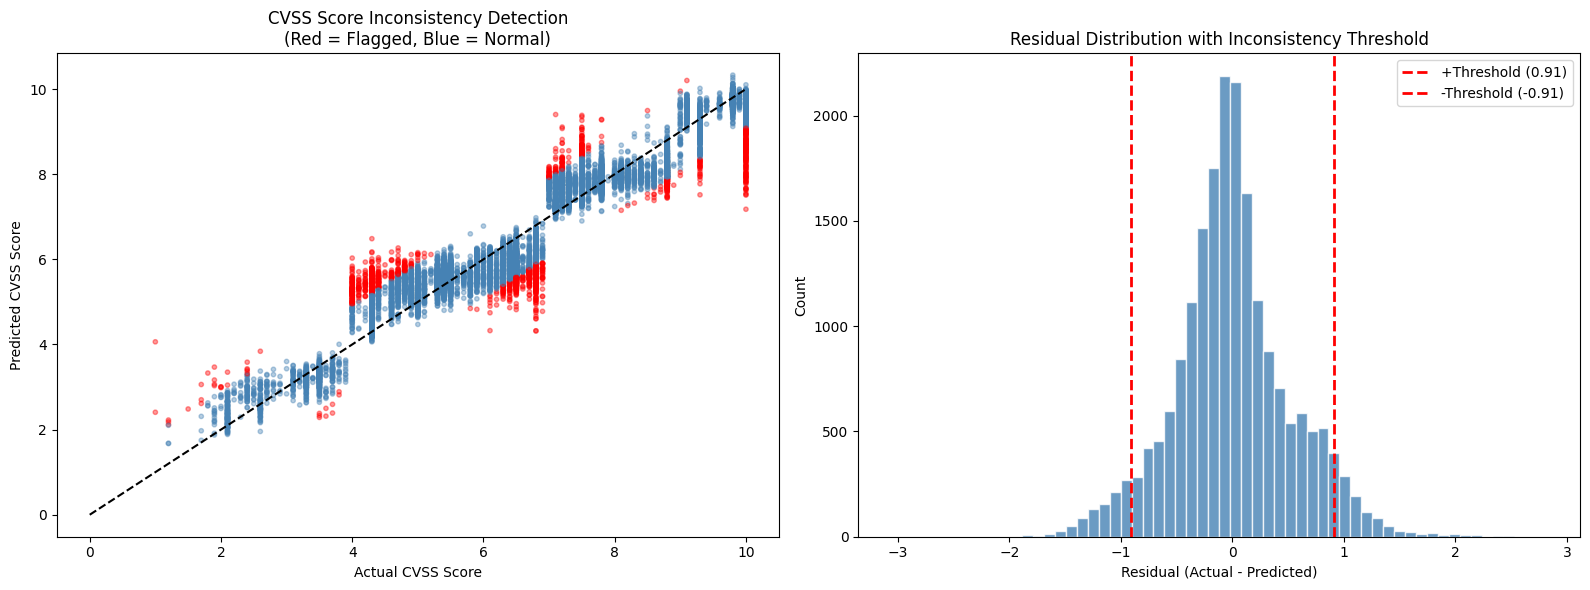

Saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = inconsistency_df["flagged"].map({True: "red", False: "steelblue"})
axes[0].scatter(
    inconsistency_df["actual_score"],
    inconsistency_df["predicted_score"],
    c=colors, alpha=0.4, s=10
)
axes[0].plot([0, 10], [0, 10], 'k--', lw=1.5)
axes[0].set_xlabel("Actual CVSS Score")
axes[0].set_ylabel("Predicted CVSS Score")
axes[0].set_title("CVSS Score Inconsistency Detection\n(Red = Flagged, Blue = Normal)")

axes[1].hist(residuals, bins=60, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(threshold, color="red", linestyle="--", lw=2, label=f"+Threshold ({threshold:.2f})")
axes[1].axvline(-threshold, color="red", linestyle="--", lw=2, label=f"-Threshold (-{threshold:.2f})")
axes[1].set_xlabel("Residual (Actual - Predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution with Inconsistency Threshold")
axes[1].legend()

plt.tight_layout()
plt.savefig("/drive/MyDrive/Colab Notebooks/inconsistency_detection.png", dpi=150)
plt.show()
print("Saved.")

Inconsistency rate by severity band:
               total  flagged  flag_rate  mean_residual  mean_abs_residual
severity_band                                                             
CRITICAL        2518      181     0.0719         0.1608             0.2830
HIGH            7189      337     0.0469        -0.0580             0.3538
LOW              876       34     0.0388        -0.0089             0.3190
MEDIUM          9417     1448     0.1538         0.0000             0.4590


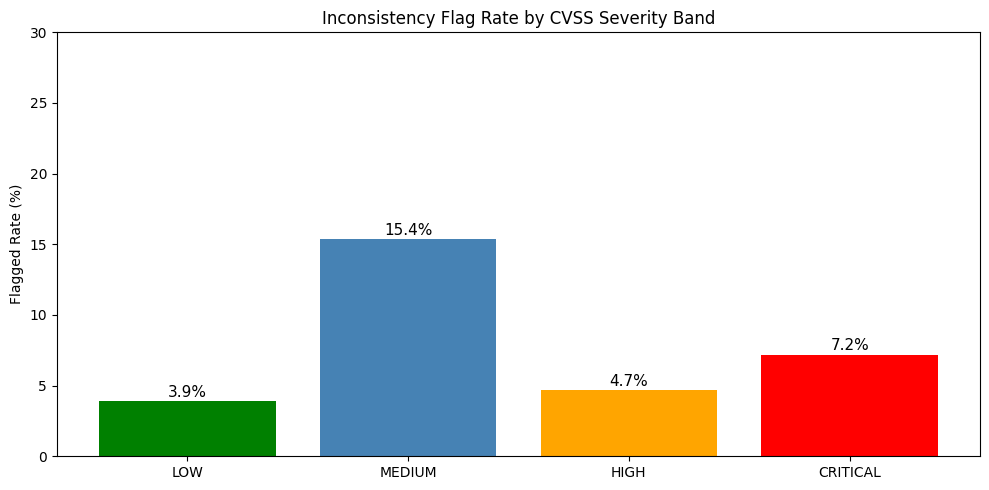

Saved.


In [ ]:
def score_to_severity(score):
    if score >= 9.0:
        return "CRITICAL"
    elif score >= 7.0:
        return "HIGH"
    elif score >= 4.0:
        return "MEDIUM"
    else:
        return "LOW"

inconsistency_df["severity_band"] = inconsistency_df["actual_score"].apply(score_to_severity)

severity_analysis = inconsistency_df.groupby("severity_band").agg(
    total=("flagged", "count"),
    flagged=("flagged", "sum"),
    flag_rate=("flagged", "mean"),
    mean_residual=("residual", "mean"),
    mean_abs_residual=("abs_residual", "mean")
).round(4)

print("Inconsistency rate by severity band:")
print(severity_analysis)

fig, ax = plt.subplots(figsize=(10, 5))
severity_order = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]
flag_rates = [severity_analysis.loc[s, "flag_rate"] * 100
              for s in severity_order if s in severity_analysis.index]
colors_bar = ["green", "steelblue", "orange", "red"]
bars = ax.bar(severity_order, flag_rates, color=colors_bar)
ax.set_ylabel("Flagged Rate (%)")
ax.set_title("Inconsistency Flag Rate by CVSS Severity Band")
ax.set_ylim(0, 30)
for bar, rate in zip(bars, flag_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{rate:.1f}%", ha="center", fontsize=11)

plt.tight_layout()
plt.savefig("/drive/MyDrive/Colab Notebooks/inconsistency_by_severity.png", dpi=150)
plt.show()
print("Saved.")

In [ ]:
flagged_cves = inconsistency_df[inconsistency_df["flagged"]].sort_values(
    "abs_residual", ascending=False
)
flagged_cves.to_csv("/drive/MyDrive/Colab Notebooks/flagged_inconsistent_cves.csv", index=False)
print(f"Saved {len(flagged_cves)} flagged CVEs.")
print(f"\nSample of flagged CVEs:")
print(flagged_cves[["cve_id", "actual_score", "predicted_score",
                     "residual", "severity_band"]].head(15))

Saved 2000 flagged CVEs.

Sample of flagged CVEs:
              cve_id  actual_score  predicted_score  residual severity_band
10170  CVE-2010-2389           1.0           4.0621   -3.0621           LOW
6698   CVE-1999-0095          10.0           7.1767    2.8233      CRITICAL
7348   CVE-2005-0491          10.0           7.5126    2.4874      CRITICAL
7286   CVE-2011-4755          10.0           7.5181    2.4819      CRITICAL
18169  CVE-2013-2710           6.8           4.3181    2.4819        MEDIUM
11465  CVE-2007-2090           6.8           4.3212    2.4788        MEDIUM
5227   CVE-1999-0799          10.0           7.5539    2.4461      CRITICAL
5135   CVE-2000-0798          10.0           7.6263    2.3737      CRITICAL
6220   CVE-2005-3449          10.0           7.6352    2.3648      CRITICAL
2414   CVE-2011-3099          10.0           7.6600    2.3400      CRITICAL
4351   CVE-2005-2290          10.0           7.6662    2.3339      CRITICAL
7582   CVE-2005-3439          10.0    